### SVMs y optimización de hiperparámetros

En este notebook trabajaremos con un dataset simulado de eventos del experimento ATLAS. Cada fila representa un evento de colisión protón–protón, y cada columna corresponde a una variable reconstruida a partir de los objetos físicos detectados en el evento: jets, leptones, energía faltante, etc.

El objetivo es distinguir entre dos tipos de eventos:

- **`ttbar`**: producción de un par top–antitop. Es un proceso mucho más frecuente.
- **`4top`**: producción de cuatro quarks top. Es un proceso mucho más raro y corresponde a nuestra clase positiva.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # Nuevo algoritmo!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # Nuevo! Para explorar los hiperparámetros del modelo

In [2]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

Leemos las características y las etiquetas  

In [7]:
features = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [9]:
features.head(10)

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.50,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.199330,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.20,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.653860,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.30,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.684610,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.80,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.871320,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.10,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.876410,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43803.10,0.572184,b,146274.0,111016.0,-0.776311,1.083980,j,1036150.0,109475.0,-2.937790,-1.518380,j,259026.0,71613.8,-1.955480,-1.726540,j,137198.0,59925.9,-1.469500,2.189410,j,95419.6,55847.5,1.123310,0.846395,j,451389.0,53178.9,-2.827840,-2.47964,j,51436.4,50713.2,0.056029,2.258540,j,152293.0,48842.5,-1.80056,-0.704609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,28100.40,-0.593429,j,458244.0,391557.0,-0.546723,0.013275,b,425427.0,328566.0,-0.728581,-2.411570,j,126694.0,116820.0,-0.350992,2.208790,j,112382.0,111318.0,0.073453,3.030960,j,3039490.0,65143.9,4.535880,1.516880,j,86235.2,65037.1,0.780704,1.50869,b,62675.6,61535.7,0.099510,0.466516,j,82070.6,45537.5,-1.18149,-3.047850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,166458.00,0.473635,j,848058.0,273398.0,-1.794510,2.763560,j,267149.0,242308.0,-0.425923,-1.534860,b,461064.0,159944.0,-1.719880,1.094360,j,75909.0,73858.8,-0.235076,-0.330519,b,201351.0,53338.2,-2.002180,-2.376840,b,38794.0,37225.5,0.187429,-2.78635,b,40323.4,36915.1,0.411490,1.844490,j,195049.0,28645.2,-2.60528,-1.434260,j,210687.0,26560.5,2.75992,0.315873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4664.13,-1.828120,j,477219.0,331550.0,-0.899484,0.698675,b,696365.0,246682.0,-1.697140,-2.285070,j,987005.0,62516.5,-3.451230,-2.207720,j,51561.9,36406.3,-0.881624,-2.923760,j,85262.1,35203.6,-1.527390,2.071480,j,202166.0,26361.8,-2.725680,-2.21350,j,56071.6,25934.6,-1.403180,1.130990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cada fila del dataset corresponde a un evento de colisión protón-protón.
Para cada evento se conoce:
- Energía faltante:
  - `MET`: energía transversa faltante (*missing transverse energy*)
  - `METphi`: ángulo azimutal asociado a la dirección de la energía faltante
- Información de cada partícula reconstruida: Para cada partícula se registra:
    - Tipo de partícula, que puede ser: electrón, positrón, fotón, jet, b-jet, muón con carga positiva, muón con carga negativa
    - 4-vector, que describe la cinemática de la partícula. En este dataset, el 4-vector incluye: energía, momento transversal, pseudorapidez $\eta$ y ángulo azimutal $\phi$


In [13]:
features.shape

(5000, 67)

In [15]:
y = np.genfromtxt('ParticleID_labels.txt', dtype = str)

In [17]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

### Objetivo del problema

Queremos entrenar un clasificador que distinga entre dos tipos de eventos:

- `ttbar`: producción de un par top-antitop.
- `4top`: producción de cuatro quarks top.

#### Necesitamos transformar las dos categorías de targets desde un string a un valor numérico, como 0/1. Podemos usar la función [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de sklearn

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #cambia las categorías a 1...N

In [23]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

In [26]:
y = le.fit_transform(y)

In [28]:
le.classes_

array(['4top', 'ttbar'], dtype='<U5')

`LabelEncoder` asigna números a las clases en el orden definido por `le.classes_`.  
Como queremos que `4top` sea la clase positiva, revisamos la codificación y, si es necesario, invertimos las etiquetas.

In [31]:
target = np.abs(y - 1)

In [32]:
target # Ahora sí

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [33]:
y.shape

(5000,)

#### Echemos un vistazo a las características

In [35]:
features.describe() #Esto excluye a las columnas con datos no-numéricos

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885e+04,41054.850000,0.054393,-0.079641,8.593460e+04,37378.30000,-0.046667,0.040528,7.975460e+04,34681.700000,0.025305,0.046141,8.315485e+04,33683.550000,0.156083,-0.015617,7.894980e+04,33328.000000,0.072709,-0.052590,7.609735e+04,30942.700000,0.035675,0.090282,7.568430e+04,29479.700000,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.9999

In [36]:
#features.info()

### Importante:

En este dataset, los NaN aparecen porque no todos los eventos tienen la misma cantidad de partículas reconstruidas.  
Al reemplazar por 0, estamos codificando implícitamente la ausencia de una partícula.

Esto puede ser razonable, pero también puede introducir una señal artificial: el modelo podría aprender no solo de las variables físicas, sino también de cuántas partículas fueron registradas.


**¿Qué podemos hacer?**

#### Opción 1: Sólo considerar las primeras 16 columnas (4 primeros productos)

De esta forma, reducimos los problemas de manipulación o de imputación de datos faltantes.


Tenemos un trade-off entre tener más features, pero si tenemos más, tendremos muchos datos faltantes que tendremos que reemplazar (imputing), o mantenemos menos features, pero el problema es más simple

In [44]:
#limitamos los features
features_lim = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16']]

In [46]:
features_lim.head()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [48]:
features_lim.describe() 

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Todavía tenemos datos faltantes (valores NaN). Los reemplazaremos con 0

In [51]:
features_lim = features_lim.fillna(0) #Llena todo lo que es NaN con 0

#### ¿Qué opina de esta estrategia?



buena primera aproximacion a una solucion aunque se podria hacer mejor

#### Si revisamos nuevamente con `describe`

In [53]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Ahora tenemos tamaños consistentes para poder usarlos como features, PERO hay que estar conciente de los efectos negativos que puede traer nuestra estrategia de imputación

## Benchmark inicial

En este notebook, el benchmark principal es el desempeño de estrategias simples antes de usar un SVM más flexible. Primero comparamos contra un clasificador que siempre predice la clase mayoritaria, ya que el dataset está desbalanceado. Luego, un clasificador aleatorio, es decir, asigna un valor aleatorio a cada clase. Y también usamos un `LinearSVC` con escalamiento como benchmark lineal: una referencia razonable para saber si necesitamos modelos más complejos, como SVM con kernels no lineales.

In [63]:
np.sum(target)/len(target) #distribución

0.1622

84\% en la etiqueta negativa, 16\% en la etiqueta positiva.

Esto significa que un clasificador que pone todo en la clase negativa (lazy classifier) tendrá un 84% de accuracy

Cómo lo haría un clasificador aleatorio que asigna un valor aleatorio a la distribución de clase?

In [59]:
#Numerical solution

acc=0
for i in range(1000): #1000 iteraciones del proceso
    x = np.random.choice(target,5000) #generamos 5000 etiquetas aleatorias
    acc += metrics.accuracy_score(target,x) #calculamos accuracy promedio en las 1000 iteraciones
print(acc/1000)

#Analytic solution 
#P(Clase 1)^2 + P(Clase 2)^2 exactitud esperada
 

print(0.8378*(0.8378) + 0.1622*0.1622)

0.7281472000000012
0.72821768


En conclusión, un clasificador aleatorio tendrá 73% accuracy, un lazy classfier tiene 83% accuracy. Este análisis es útil para tener una expectativa de qué es un "buen resultado" y qué significa una mejora significativa


### Ahora empezaremos con un modelo lineal  model = SVC()

Definimos una estrategia CV, establecemos un benchmark para un modelo lineal no regularization (parámetro C muy alto)

**Antes de correr el modelo, discuta:**

1. ¿Esperamos que un modelo lineal separe bien eventos `ttbar` y `4top`?
2. ¿Qué significaría que el modelo lineal tenga una accuracy cercana al clasificador mayoritario?
3. ¿Qué métrica sería más relevante si queremos detectar eventos `4top`: accuracy, precision, recall o F1-score?

1. no tanto
2. que no es muy bueno
3. recall

In [65]:
bmodel = LinearSVC(dual = False, C=1000) 
# Para modelo lineal, se prefiere dual=False cuando  n_samples > n_features.
#( el primal trabaja con las features, el dual trabaja con los alpha_i que estan asociados al numero de muestras)
# Si no, no va a converger!


**Qué signifca la elección de C grande?**

In [67]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101) 

In [69]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)


In [70]:
l_benchmark_lim

{'fit_time': array([0.24253345, 0.00992584, 0.01000237, 0.0080018 , 0.00900149]),
 'score_time': array([0.04301023, 0.00200081, 0.00100017, 0.00100112, 0.00200057]),
 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]),
 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}

In [73]:
np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)

(0.832, 0.005)

El promedio de accuracy para este caso parece alto, pero es igual de alto que el lazy classifier.
Podemos chequear las etiquetas con `cross_val_predict`, que compila las etiquetas predichas cuando cada objeto estaba en el fold test

In [76]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)

In [78]:
ypred_bench_lim

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

### Pregunta: Qué podríamos haber hecho antes de haber construído el modelo SVM?

<details>
<summary>Mostrar explicación</summary>

### Escalar!

Los SVM son sensibles a la escala de las variables porque trabajan en el espacio de características.
La optimización  depende de productos punto entre pares de ejemplos:

$$
\mathbf{x}_i \cdot \mathbf{x}_j
$$

Por eso escalamos las features antes de entrenar un SVM. Una opción común es usar `StandardScaler`, que transforma cada feature para que tenga media 0 y desviación estándar 1.



</details>


In [80]:
from sklearn.pipeline import make_pipeline #Podemos construir varios pasos al mismo tiempo

¿Por qué usamos Pipeline?

Porque en validación cruzada, el escalamiento debe aprenderse usando solo los datos de entrenamiento de cada fold.  
Si escalamos todo el dataset antes de hacer CV, estaríamos usando información del conjunto de prueba para transformar los datos.  
Eso sería una forma sutil de data leakage.

[`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)  permite encadenar varios pasos de preprocesamiento y modelado en un solo objeto.


In [83]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))
#modelo benchmark (de referencia)
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [85]:
benchmark_lim_piped

{'fit_time': array([0.00800133, 0.00700235, 0.00700164, 0.00700116, 0.00700092]),
 'score_time': array([0.00200057, 0.00199986, 0.00200105, 0.00200057, 0.00200009]),
 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]),
 'train_score': array([0.89575, 0.895  , 0.895  , 0.89825, 0.89275])}

In [87]:
np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3)

(0.893, 0.004)

In [89]:
np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3)

(0.895, 0.002)

Esto es una mejora! 


Ahora necesitamos **diagnosticar** nuestro modelo:

Si comparamos el score para prueba y entrenamiento, notamos que hay un problema....
Miremos la curva de aprendizaje, que nos ayudará a mirar esto mejor y nos indicará si necesitamos más datos

### Curva de aprendizaje

In [97]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)
 
    plt.ylabel("Accuracy score",fontsize = 14)
    
    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

In [99]:
cv

StratifiedKFold(n_splits=5, random_state=101, shuffle=True)

<module 'matplotlib.pyplot' from 'E:\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

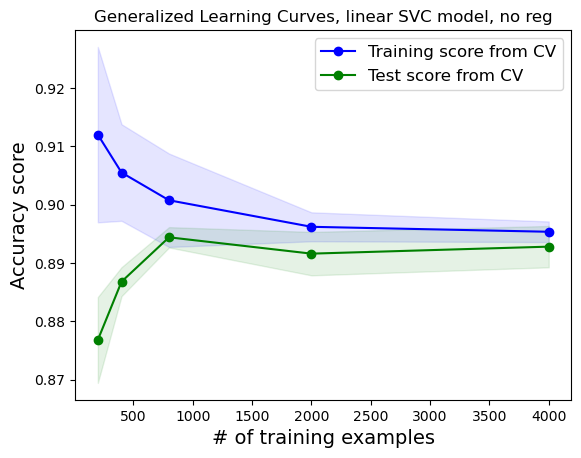

In [101]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg', 
                    features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = cv)

In [103]:
# Obtener predicciones usando validación cruzada
ypred_linear = cross_val_predict(
    piped_model,
    features_lim,
    target,
    cv=cv
)

#### Genere una matriz de confusión para esre modelo y evalúe el desempeño del modelo a partir del resultado.

también puede usar la función [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) de `sklearn`

In [107]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [109]:
cm = confusion_matrix(target, ypred_linear)
cm

array([[4048,  141],
       [ 395,  416]], dtype=int64)

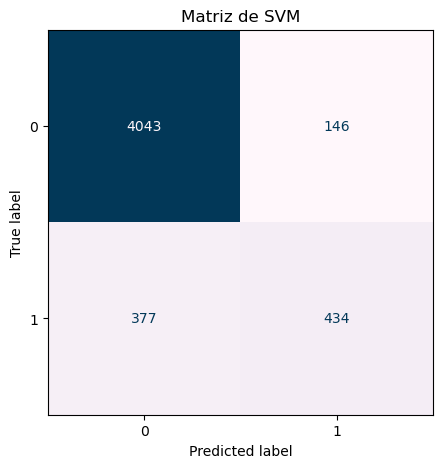

In [131]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de SVM")
plt.show()

## Conclusiones del benchmark lineal

1. En la curva de aprendizaje, ¿los scores de entrenamiento y validación son altos o bajos?  
   ¿Están separados o son parecidos?

2. ¿La curva sugiere alto bias o alta variance?  
   Justifique usando la relación entre score de entrenamiento y validación.

3. Considerando que usamos \(C=1000\), ¿qué nos dice este resultado sobre la capacidad del modelo lineal?

4. En la matriz de confusión, ¿el modelo detecta bien los eventos `4top` o tiende a clasificarlos como `ttbar`?

5. ¿qué métrica muestra mejor el problema con la clase minoritaria: accuracy, precision, recall o F1-score?

6. ¿El modelo lineal supera realmente los benchmarks ingenuos, o su buen desempeño se explica principalmente por el desbalance de clases?

7. ¿Qué evidencia nos indica que necesitamos un modelo más flexible que una frontera lineal?

1. los scores son mejores que los del lazy classifier ademas entrenamineto y prueba son parecidos
2. alto bias ya que prueba y entrenamiento son parecidos y entrenamiento no tienen un puntaje muy bueno
3. que puede que no sea el modelo adecuado para este problema
4. tiende a clasificarlos como ttbar
6. recall
7. el desbalance de clases afecta el desempeño
8. el alto bias observado en la curva de aprendizaje

## Optimización de hiperparámetros

[`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html)selecciona los hiperparámetros que obtienen el mejor desempeño promedio en validación cruzada. Sin embargo, ese score puede ser optimista, porque los mismos folds de validación se usaron para elegir la mejor combinación de hiperparámetros.
Para estimar mejor el desempeño esperado en datos nuevos, se puede usar **validación cruzada anidada**. En este procedimiento, una validación cruzada interna selecciona los hiperparámetros, mientras que una validación cruzada externa evalúa el modelo seleccionado.
La idea central es no usar la misma información para elegir el modelo y para reportar su desempeño final.

La validación cruzada anidada es más rigurosa, pero no siempre vale la pena implementarla. Puede ser muy costosa, porque requiere repetir la búsqueda de hiperparámetros dentro de cada fold externo.En este notebook usaremos `GridSearchCV` para seleccionar hiperparámetros y comparar modelos, pero debemos recordar que el mejor score obtenido puede ser algo optimista. Si el objetivo fuera reportar un resultado final de investigación de manera rigurosa, sería mejor usar un conjunto de prueba independiente o validación cruzada anidada.

In [113]:
#ahora usamos la version general SVC y no la lineal, para cambiar el kernel
piped_model = make_pipeline(StandardScaler(), SVC()) 

piped_model.get_params() # esto nos muestra los parámetros para el scaler y el clasificador

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### Podemos definir un diccionario de valores parámetros para correr la optimización

Note que esto tomará tiempo (~3 min en mi computador)

Una vez que corramos esta celda, el objeto modelo tendra atributos de "best_score_", "best_params_" y "best_estimator_", que nos da acceso al estimador óptimo y "cv_results_" que pueden ser utilizados para visualizar la performance de todos los modelo

In [115]:
%%time
#optimizando SVC, TODAVIA NO ES CV ANIDADA!

#Probamos kernel polinomial y gaussiano, parámetros gamma y degree, 
# además del parámetro de regularización
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
              'svc__degree': [2, 4, 8]}

# CV para todos los valores de los parámetros del GridSearch
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params, best score: 0.8946 {'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
CPU times: total: 1.62 s
Wall time: 5min 57s


####  Ahora, visualizamos los modelos en un dataframe, y los rankeamos de acuerdo a los scores de prueba.

Miraremos el promedio y desviación estándar de los test scores, el promedio de los train scores, para evaluar si son distintos  y la significancia del resultado, y fitting time, para elegir el modelo más rápido en vez del mejor modelo, si es que los scores son comparables

In [117]:
scores_lim = pd.DataFrame(model.cv_results_)

scores_lim.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_svc__C', 'param_svc__degree', 'param_svc__gamma',
       'param_svc__kernel', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='object')

In [119]:
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
29,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8946,0.004841,0.90050,0.154203
45,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8946,0.004841,0.90050,0.148953
37,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8946,0.004841,0.90050,0.155809
61,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8944,0.005004,0.91205,0.170254
69,"{'svc__C': 10.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8944,0.005004,0.91205,0.170114
53,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8944,0.005004,0.91205,0.180504
47,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8940,0.004561,0.93955,0.214647
39,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8940,0.004561,0.93955,0.212454
31,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8940,0.004561,0.93955,0.229570
27,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8936,0.006530,0.92200,0.191901


Observamos que el kernel rbf es preferido constantemente, los valores de $C$ y $\gamma$ no afectan demasiado los scores. GridSearch es insensible a combinaciones de parámetros irrelevantes, por ejemplo, los tres primeros modelos son idénticos porque el grado del kernel polinomial no afecta al kernel rbf.

#### Podemos aislar un solo tipo de kernel 

In [121]:
scores_lim[scores_lim['param_svc__kernel'] == 'poly'][['params','mean_test_score','std_test_score',\
                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
54,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8776,0.002577,0.88680,1.291694
100,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8774,0.002498,0.88675,1.260098
102,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8772,0.003544,0.88800,123.723877
58,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8772,0.005706,0.96125,0.366751
38,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8770,0.005967,0.96185,0.357320
78,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8768,0.003816,0.88760,12.895342
98,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8768,0.003816,0.88785,38.004721
26,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8768,0.005307,0.88165,0.218652
74,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8768,0.003487,0.88735,4.207618
30,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8768,0.005980,0.88435,0.304126


In [123]:
best_model = model.best_estimator_

ypred_best = cross_val_predict(
    best_model,
    features_lim,
    target,
    cv=cv
)

**Construya la matriz de confusión para el modelo optimizado**

Preguntas:

- ¿Cuál es la accuracy del modelo optimizado?
- ¿Cuál es la precision para la clase 4top?
- ¿Cuál es el recall para la clase 4top?
- ¿Cuál es el F1-score para la clase 4top?
- ¿Qué métrica mejoró más respecto al benchmark lineal?
- ¿Qué métrica empeoró o cambió muy poco?
- ¿La mejora en accuracy refleja una mejora real para la clase 4top?
- ¿El modelo optimizado detecta mejor la clase minoritaria que el benchmark lineal?

Complete la tabla de comparación


| Modelo            | Accuracy | Precision `4top` | Recall `4top` | F1-score `4top` | Comentario |
| ----------------- | -------: | ---------------: | ------------: | --------------: | ---------- |
| Benchmark lineal  |  0.896   |   0.746          |  0.547        |      0.631      |  mejor accuracy recall f1          |
| Modelo optimizado |  0.895   |   0.749          |  0.535        |      0.624      |  mejor precision          |

- ¿El modelo optimizado mejora todas las métricas o solo algunas?
- Si una métrica mejora pero otra empeora, ¿cómo decidiría cuál modelo es mejor?
- ¿La mejora justifica usar un modelo más complejo?


1. 0.895
2. 0.7949
3. 0.535
4. 0.624
5. precision
6. accuracy recall y f1
7. no
8. no
9. mejora solo una metrica
10. basandome en cual tiene mejor recall
11. no

In [135]:
cm1 = confusion_matrix(target, ypred_best)
cm1

array([[4043,  146],
       [ 377,  434]], dtype=int64)

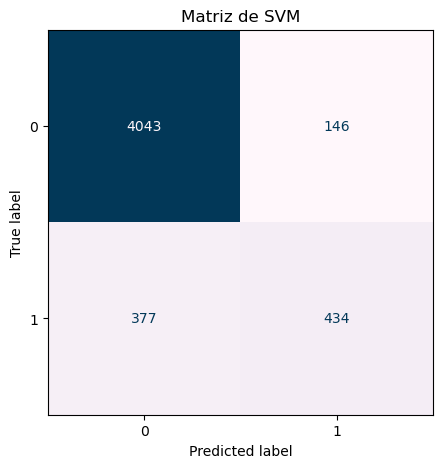

In [137]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de SVM")
plt.show()

In [154]:
benchmark_best = cross_validate(best_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [155]:
benchmark_best_pr = cross_validate(best_model, features_lim, target, cv = cv, scoring = 'precision', return_train_score=True)

In [156]:
benchmark_best_re = cross_validate(best_model, features_lim, target, cv = cv, scoring = 'recall', return_train_score=True)

In [157]:
benchmark_best_f1 = cross_validate(best_model, features_lim, target, cv = cv, scoring = 'f1', return_train_score=True)

In [176]:
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [177]:
benchmark_lim_piped_pr = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'precision', return_train_score=True)

In [178]:
benchmark_lim_piped_re = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'recall', return_train_score=True)

In [179]:
benchmark_lim_piped_f1 = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'f1', return_train_score=True)

In [172]:
print("accuracy:", np.round(benchmark_best['test_score'].mean(),3), np.round(benchmark_best['test_score'].std(), 3))
print("precision:", np.round(benchmark_best_pr['test_score'].mean(),3), np.round(benchmark_best_pr['test_score'].std(), 3))
print("recall:", np.round(benchmark_best_re['test_score'].mean(),3), np.round(benchmark_best_re['test_score'].std(), 3))
print("F1:", np.round(benchmark_best_f1['test_score'].mean(),3), np.round(benchmark_best_f1['test_score'].std(), 3))

accuracy: 0.895 0.002
precision: 0.749 0.015
recall: 0.535 0.005
F1: 0.624 0.004


In [174]:
print("accuracy:", np.round(benchmark_best['train_score'].mean(),3), np.round(benchmark_best['train_score'].std(), 3))
print("precision:", np.round(benchmark_best_pr['train_score'].mean(),3), np.round(benchmark_best_pr['train_score'].std(), 3))
print("recall:", np.round(benchmark_best_re['train_score'].mean(),3), np.round(benchmark_best_re['train_score'].std(), 3))
print("F1:", np.round(benchmark_best_f1['train_score'].mean(),3), np.round(benchmark_best_f1['train_score'].std(), 3))

accuracy: 0.9 0.001
precision: 0.771 0.004
recall: 0.55 0.003
F1: 0.642 0.003


In [184]:
print("accuracy:", np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3))
print("precision:", np.round(benchmark_lim_piped_pr['test_score'].mean(),3), np.round(benchmark_lim_piped_pr['test_score'].std(), 3))
print("recall:", np.round(benchmark_lim_piped_re['test_score'].mean(),3), np.round(benchmark_lim_piped_re['test_score'].std(), 3))
print("F1:", np.round(benchmark_lim_piped_f1['test_score'].mean(),3), np.round(benchmark_lim_piped_f1['test_score'].std(), 3))

accuracy: 0.896 0.006
precision: 0.746 0.02
recall: 0.547 0.03
F1: 0.631 0.026


In [186]:
print("accuracy:", np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3))
print("precision:", np.round(benchmark_lim_piped_pr['train_score'].mean(),3), np.round(benchmark_lim_piped_pr['train_score'].std(), 3))
print("recall:", np.round(benchmark_lim_piped_re['train_score'].mean(),3), np.round(benchmark_lim_piped_re['train_score'].std(), 3))
print("F1:", np.round(benchmark_lim_piped_f1['train_score'].mean(),3), np.round(benchmark_lim_piped_f1['train_score'].std(), 3))

accuracy: 0.921 0.001
precision: 0.839 0.007
recall: 0.637 0.007
F1: 0.724 0.004


#### Diagnóstico final

- ¿Qué modelo elegiría para reportar y por qué?
- ¿Qué limitación importante todavía tiene el modelo?

el lineal ya que es mejor en 3 de 4 metricas y no compensa aumentar la complejidad

el dataset

## Actividad final: mejorar el modelo

Hasta ahora usamos un conjunto limitado de features para construir y optimizar nuestros modelos. Sin embargo, el desempeño de un modelo no depende solo del algoritmo o de los hiperparámetros: también depende de la información que le entregamos.

En este dataset, cada evento contiene información de varias partículas reconstruidas. Como los eventos `4top` suelen ser más complejos que los eventos `ttbar`, es razonable pensar que usar más información del evento podría ayudar al modelo a distinguir mejor ambas clases.

**Proponga una estrategia para mejorar el modelo explorando nuevas features o usando una representación más completa de los eventos.**

Puede considerar, por ejemplo:

- incluir información de más partículas;
- usar todas las partículas disponibles;
- construir variables derivadas;
- modificar el tratamiento de valores faltantes;
- comparar distintos subconjuntos de features;
- cambiar la métrica usada para optimizar el modelo.

Luego evalúe si su propuesta mejora el desempeño respecto al modelo anterior.

### Preguntas

1. ¿Qué cambio hizo?
4. ¿Mejoró la detección de eventos `4top`?
5. ¿Qué ocurrió con la matriz de confusión?
6. ¿La mejora justifica el aumento de complejidad?
7. ¿Qué aprendió sobre la importancia de las features en este problema?

1. usar todas la features
2. si
3. mejoro mucho consiguiendo más aciertos y menos errores en todos los casos
4. si
5. las features pueden ser determinantes a la hora de hacer un buen modelo

## modelo ##

In [190]:
features.head(10)

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.50,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.199330,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.20,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.653860,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.30,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.684610,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.80,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.871320,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.10,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.876410,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43803.10,0.572184,b,146274.0,111016.0,-0.776311,1.083980,j,1036150.0,109475.0,-2.937790,-1.518380,j,259026.0,71613.8,-1.955480,-1.726540,j,137198.0,59925.9,-1.469500,2.189410,j,95419.6,55847.5,1.123310,0.846395,j,451389.0,53178.9,-2.827840,-2.47964,j,51436.4,50713.2,0.056029,2.258540,j,152293.0,48842.5,-1.80056,-0.704609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,28100.40,-0.593429,j,458244.0,391557.0,-0.546723,0.013275,b,425427.0,328566.0,-0.728581,-2.411570,j,126694.0,116820.0,-0.350992,2.208790,j,112382.0,111318.0,0.073453,3.030960,j,3039490.0,65143.9,4.535880,1.516880,j,86235.2,65037.1,0.780704,1.50869,b,62675.6,61535.7,0.099510,0.466516,j,82070.6,45537.5,-1.18149,-3.047850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,166458.00,0.473635,j,848058.0,273398.0,-1.794510,2.763560,j,267149.0,242308.0,-0.425923,-1.534860,b,461064.0,159944.0,-1.719880,1.094360,j,75909.0,73858.8,-0.235076,-0.330519,b,201351.0,53338.2,-2.002180,-2.376840,b,38794.0,37225.5,0.187429,-2.78635,b,40323.4,36915.1,0.411490,1.844490,j,195049.0,28645.2,-2.60528,-1.434260,j,210687.0,26560.5,2.75992,0.315873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4664.13,-1.828120,j,477219.0,331550.0,-0.899484,0.698675,b,696365.0,246682.0,-1.697140,-2.285070,j,987005.0,62516.5,-3.451230,-2.207720,j,51561.9,36406.3,-0.881624,-2.923760,j,85262.1,35203.6,-1.527390,2.071480,j,202166.0,26361.8,-2.725680,-2.21350,j,56071.6,25934.6,-1.403180,1.130990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [192]:
features["Type_1"].value_counts()

Type_1
j    3239
b    1761
Name: count, dtype: int64

In [194]:
features["Type_2"].value_counts()

Type_2
j     3321
b     1660
e+       6
m+       4
e-       3
g        2
m-       1
Name: count, dtype: int64

In [196]:
features["Type_3"].value_counts()

Type_3
j     3611
b     1227
m-      32
m+      28
e+      22
e-      20
g       10
Name: count, dtype: int64

In [198]:
features["Type_4"].value_counts()

Type_4
j     3512
b      943
m-      71
m+      65
e+      52
e-      47
g       27
Name: count, dtype: int64

In [200]:
features["Type_5"].value_counts()

Type_5
j     2973
b      653
m+     116
m-      96
e-      76
e+      66
g       22
Name: count, dtype: int64

In [202]:
types=features[["Type_1","Type_2","Type_3","Type_4","Type_5","Type_6","Type_7","Type_8","Type_9","Type_10","Type_11","Type_12","Type_13"]]

In [204]:
types

,Type_1,Type_2,Type_3,Type_4,Type_5,Type_6,Type_7,Type_8,Type_9,Type_10,Type_11,Type_12,Type_13
ID,,,,,,,,,,,,,
0,j,j,b,j,m+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,j,j,e-,e+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,j,b,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,j,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,j,b,j,b,j,j,j,j,j,j,NaN,NaN,NaN
4996,j,j,j,b,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,b,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [206]:
count=types
count

,Type_1,Type_2,Type_3,Type_4,Type_5,Type_6,Type_7,Type_8,Type_9,Type_10,Type_11,Type_12,Type_13
ID,,,,,,,,,,,,,
0,j,j,b,j,m+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,j,j,e-,e+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,j,b,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,j,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,j,b,j,b,j,j,j,j,j,j,NaN,NaN,NaN
4996,j,j,j,b,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,b,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [208]:
count=count.fillna(0)

In [210]:
count=count.replace("j",1.0)

In [212]:
count=count.replace("b",1.0)

C:\Users\jorge\AppData\Local\Temp\ipykernel_7896\1198711881.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count=count.replace("b",1.0)


In [214]:
count=count.replace("m+",1.0)

In [216]:
count=count.replace("m-",1.0)

In [218]:
count=count.replace("e-",1.0)

In [220]:
count=count.replace("e+",1.0)

C:\Users\jorge\AppData\Local\Temp\ipykernel_7896\2009218482.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count=count.replace("e+",1.0)


In [222]:
count=count.replace("g",1.0)

C:\Users\jorge\AppData\Local\Temp\ipykernel_7896\3724099288.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  count=count.replace("g",1.0)


In [224]:
count

,Type_1,Type_2,Type_3,Type_4,Type_5,Type_6,Type_7,Type_8,Type_9,Type_10,Type_11,Type_12,Type_13
ID,,,,,,,,,,,,,
0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
4996,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [226]:
col=count.columns
col

Index(['Type_1', 'Type_2', 'Type_3', 'Type_4', 'Type_5', 'Type_6', 'Type_7',
       'Type_8', 'Type_9', 'Type_10', 'Type_11', 'Type_12', 'Type_13'],
      dtype='object')

In [228]:
n=0
counts=[]
while n<5000:
    sum=0
    for c in col:
        sum+=count[c][n]
    counts.append(sum)
    n+=1


In [230]:
counts1=pd.DataFrame(counts,columns=["cantidad"])
counts1

,cantidad
0,5.0
1,4.0
2,5.0
3,5.0
4,5.0
...,...
4995,10.0
4996,5.0
4997,5.0
4998,9.0


In [232]:
tipos=types
tipos

,Type_1,Type_2,Type_3,Type_4,Type_5,Type_6,Type_7,Type_8,Type_9,Type_10,Type_11,Type_12,Type_13
ID,,,,,,,,,,,,,
0,j,j,b,j,m+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,j,j,e-,e+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,j,b,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,j,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,j,b,j,b,j,j,j,j,j,j,NaN,NaN,NaN
4996,j,j,j,b,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,b,j,j,j,j,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [234]:
tipos=tipos.fillna(0)

In [236]:
tipos=tipos.replace("j",1.0)

In [238]:
tipos=tipos.replace("b",2.0)

C:\Users\jorge\AppData\Local\Temp\ipykernel_7896\1586701439.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tipos=tipos.replace("b",2.0)


In [240]:
tipos=tipos.replace("m+",3.0)

In [242]:
tipos=tipos.replace("m-",4.0)

In [244]:
tipos=tipos.replace("e-",5.0)

In [246]:
tipos=tipos.replace("e+",6.0)

C:\Users\jorge\AppData\Local\Temp\ipykernel_7896\3130393348.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tipos=tipos.replace("e+",6.0)


In [248]:
tipos=tipos.replace("g",7.0)

C:\Users\jorge\AppData\Local\Temp\ipykernel_7896\346977086.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tipos=tipos.replace("g",7.0)


In [250]:
tipos

,Type_1,Type_2,Type_3,Type_4,Type_5,Type_6,Type_7,Type_8,Type_9,Type_10,Type_11,Type_12,Type_13
ID,,,,,,,,,,,,,
0,1.0,1.0,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
4996,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [252]:
fe=features.drop(columns=['Type_1', 'Type_2', 'Type_3', 'Type_4', 'Type_5', 'Type_6', 'Type_7',
       'Type_8', 'Type_9', 'Type_10', 'Type_11', 'Type_12', 'Type_13'])

In [325]:
datos_finales=pd.concat([fe,tipos,counts1], axis=1)

In [327]:
datos_finales

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52,Type_1,Type_2,Type_3,Type_4,Type_5,Type_6,Type_7,Type_8,Type_9,Type_10,Type_11,Type_12,Type_13,cantidad
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.199330,-1.302800,85230.6,70102.4,-0.645689,-1.659540,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.653860,-3.129630,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.684610,1.389690,26840.0,24469.3,-0.388937,-1.647260,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.871320,0.817631,28235.4,25887.9,-0.411528,2.024290,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.876410,0.865381,746585.0,26219.3,4.041820,-0.874169,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,269074.0,-1.274730,495577.0,362590.0,-0.791914,1.671250,328278.0,224827.0,0.922952,-1.284970,2628790.0,178652.0,-3.380790,2.922260,303713.0,156021.0,-1.284190,0.436475,555572.0,116170.0,2.244670,-2.079480,173426.0,64470.5,1.644410,2.545220,65465.9,53244.8,-0.660150,-0.089563,47959.1,47171.9,-0.100525,2.179240,150048.0,23931.7,2.52114,1.527640,82489.5,23426.6,1.92712,1.00469,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,10.0
4996,12385.8,0.986871,258932.0,133559.0,-1.276540,2.970100,87822.2,73895.0,0.604704,-0.646550,104199.0,67035.4,-1.003020,-0.909438,60343.9,38512.4,-1.013560,0.770876,55479.0,33020.8,1.101410,1.617520,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
4997,32762.8,3.057630,122222.0,79947.8,0.983920,-0.399231,260623.0,49940.6,2.334630,0.555659,56696.1,49853.1,0.422515,-3.014610,36338.9,25777.1,0.850436,0.672009,262419.0,25037.1,-3.039990,2.820440,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,0.0,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [333]:
%%time
#optimizando SVC, TODAVIA NO ES CV ANIDADA!

#Probamos kernel polinomial y gaussiano, parámetros gamma y degree, 
# además del parámetro de regularización
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
              'svc__degree': [2, 4, 8]}

# CV para todos los valores de los parámetros del GridSearch
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = -1, return_train_score=True)
model.fit(datos_finales,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params, best score: 0.9418 {'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}
CPU times: total: 1.91 s
Wall time: 1min 2s


In [371]:
best_model2 = model.best_estimator_

ypred_best2 = cross_val_predict(
    best_model,
    datos_finales,
    target,
    cv=cv
)

In [347]:
benchmark_best2 = cross_validate(best_model2, datos_finales, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [348]:
benchmark_best_pr2 = cross_validate(best_model2, datos_finales, target, cv = cv, scoring = 'precision', return_train_score=True)

In [349]:
benchmark_best_re2 = cross_validate(best_model2, datos_finales, target, cv = cv, scoring = 'recall', return_train_score=True)

In [350]:
benchmark_best_f12 = cross_validate(best_model2, datos_finales, target, cv = cv, scoring = 'f1', return_train_score=True)

In [351]:
print("accuracy:", np.round(benchmark_best2['test_score'].mean(),3), np.round(benchmark_best2['test_score'].std(), 3))
print("precision:", np.round(benchmark_best_pr2['test_score'].mean(),3), np.round(benchmark_best_pr2['test_score'].std(), 3))
print("recall:", np.round(benchmark_best_re2['test_score'].mean(),3), np.round(benchmark_best_re2['test_score'].std(), 3))
print("F1:", np.round(benchmark_best_f12['test_score'].mean(),3), np.round(benchmark_best_f12['test_score'].std(), 3))

accuracy: 0.941 0.012
precision: 0.847 0.043
recall: 0.781 0.04
F1: 0.812 0.038


In [352]:
print("accuracy:", np.round(benchmark_best2['train_score'].mean(),3), np.round(benchmark_best2['train_score'].std(), 3))
print("precision:", np.round(benchmark_best_pr2['train_score'].mean(),3), np.round(benchmark_best_pr2['train_score'].std(), 3))
print("recall:", np.round(benchmark_best_re2['train_score'].mean(),3), np.round(benchmark_best_re2['train_score'].std(), 3))
print("F1:", np.round(benchmark_best_f12['train_score'].mean(),3), np.round(benchmark_best_f12['train_score'].std(), 3))

accuracy: 0.95 0.002
precision: 0.871 0.008
recall: 0.81 0.006
F1: 0.839 0.006


In [375]:
cm3 = confusion_matrix(target, ypred_best2)
cm3

array([[4051,  138],
       [ 163,  648]], dtype=int64)

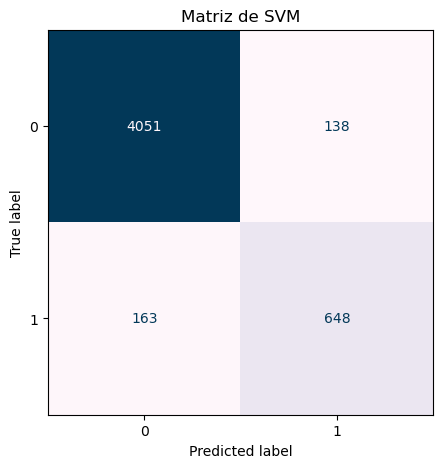

In [377]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de SVM")
plt.show()